
# Projeto 1 – Visão Computacional
Detecção de uso de máscara em faces com pipeline clássico: detecção → extração de características → classificação → avaliação cropped vs. fim‑a‑fim.



In [1]:
import os, json, math, xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from joblib import dump, load
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, hog

ROOT = Path(r"C:\Users\Fernanda\Desktop\projeto_mascara").resolve()
DATA_RAW      = ROOT / "data" / "raw"              
IMG_DIR       = DATA_RAW / "images"
ANN_DIR       = DATA_RAW / "annotations"
DATA_INTERIM  = ROOT / "data" / "interim" / "roi_face"
DATA_PROCESSED= ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "models"
FIG_DIR       = ROOT / "reports" / "figures"

for p in [DATA_INTERIM, DATA_PROCESSED, MODELS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW :", DATA_RAW)
print("Esperado:", IMG_DIR, "e", ANN_DIR)

assert IMG_DIR.exists() and ANN_DIR.exists(), (
    "Não encontrei data/raw/images e data/raw/annotations no caminho indicado.\n"
    "Verifique o ROOT acima ou mova o dataset para esse layout."
)

pngs = list(IMG_DIR.glob("*.png"))
jpgs = list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.jpeg"))
xmls = list(ANN_DIR.glob("*.xml"))
print(f"Imagens: {len(pngs)+len(jpgs)}  |  XML: {len(xmls)}")

ROOT: C:\Users\Fernanda\Desktop\projeto_mascara
RAW : C:\Users\Fernanda\Desktop\projeto_mascara\data\raw
Esperado: C:\Users\Fernanda\Desktop\projeto_mascara\data\raw\images e C:\Users\Fernanda\Desktop\projeto_mascara\data\raw\annotations
Imagens: 853  |  XML: 853



## 1) Parser VOC → lista de anotações


In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET
from tqdm import tqdm

CLASSES = ["with_mask", "without_mask", "mask_weared_incorrect"]

def parse_voc(xml_path: Path):
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    fname = (root.findtext("filename") or "").strip()
    objects = []
    for obj in root.findall("object"):
        cname = (obj.findtext("name") or "").strip()
        if cname not in CLASSES:
            continue
        bnd = obj.find("bndbox")
        x1 = int(float(bnd.findtext("xmin"))); y1 = int(float(bnd.findtext("ymin")))
        x2 = int(float(bnd.findtext("xmax"))); y2 = int(float(bnd.findtext("ymax")))
        objects.append({"label": cname, "bbox": (x1, y1, x2, y2)})
    return fname, objects

def find_image(fname: str, img_root: Path):
    """
    Tenta localizar a imagem por nome exato; se não achar, busca por 'stem' com extensões comuns.
    Evita quebrar quando o XML referencia .jpg e o arquivo é .png (ou vice-versa).
    """
    cand = img_root / fname
    if cand.exists():
        return cand
    stem = Path(fname).stem
    for ext in (".png", ".jpg", ".jpeg", ".bmp"):
        hits = list(img_root.rglob(stem + ext))
        if hits:
            return hits[0]
    hits = list(img_root.rglob(fname))
    return hits[0] if hits else None

def load_annotations(ann_dir: Path, img_dir: Path):
    ann_paths = sorted(Path(ann_dir).rglob("*.xml"))
    data = []
    for ap in tqdm(ann_paths, desc="VOC XML"):
        try:
            fname, objs = parse_voc(ap)
        except Exception:
            continue
        if not fname or not objs:
            continue
        img_path = find_image(fname, img_dir)
        if not img_path:
            continue
        for o in objs:
            data.append({
                "image_path": str(img_path),
                "label": o["label"],
                "bbox":  o["bbox"]
            })
    return data

ANN_DIR = DATA_RAW / "annotations"
IMG_DIR = DATA_RAW / "images"

assert ANN_DIR.exists(), f"Não encontrei: {ANN_DIR}"
assert IMG_DIR.exists(), f"Não encontrei: {IMG_DIR}"

anno_list = load_annotations(ANN_DIR, IMG_DIR)
print("Total de faces anotadas:", len(anno_list))

from collections import Counter
print("Distribuição:", Counter([d["label"] for d in anno_list]))

anno_list[:2]

VOC XML: 100%|██████████| 853/853 [00:00<00:00, 1960.88it/s]

Total de faces anotadas: 4072
Distribuição: Counter({'with_mask': 3232, 'without_mask': 717, 'mask_weared_incorrect': 123})


[{'image_path': 'C:\\Users\\Fernanda\\Desktop\\projeto_mascara\\data\\raw\\images\\maksssksksss0.png',
  'label': 'without_mask',
  'bbox': (79, 105, 109, 142)},
 {'image_path': 'C:\\Users\\Fernanda\\Desktop\\projeto_mascara\\data\\raw\\images\\maksssksksss0.png',
  'label': 'with_mask',
  'bbox': (185, 100, 226, 144)}]


## 2) Geração de ROIs (recortes de face) e *dataset* tabular


In [4]:

def safe_crop(img, bbox, pad=0.05):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = bbox
    dx = int(pad * (x2 - x1))
    dy = int(pad * (y2 - y1))
    x1 = max(0, x1 - dx); y1 = max(0, y1 - dy)
    x2 = min(w-1, x2 + dx); y2 = min(h-1, y2 + dy)
    return img[y1:y2, x1:x2]

def build_roi_dataset(anno, out_dir, save_images=False, size=(128,128)):
    X_imgs, y_labels = [], []
    counts = {k:0 for k in CLASSES}
    for a in tqdm(anno, desc="Recortando faces"):
        img = cv2.imread(a["image_path"])
        if img is None: 
            continue
        roi = safe_crop(img, a["bbox"], pad=0.08)
        if roi.size == 0:
            continue
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
        X_imgs.append(gray)
        y_labels.append(a["label"])
        counts[a["label"]] += 1
        if save_images:
            cls_dir = Path(out_dir) / a["label"]
            cls_dir.mkdir(parents=True, exist_ok=True)
            fname = Path(a["image_path"]).stem
            idx = counts[a["label"]]
            cv2.imwrite(str(cls_dir / f"{fname}_{idx}.png"), gray)
    return np.array(X_imgs), np.array(y_labels)

X_imgs, y = build_roi_dataset(anno_list, DATA_INTERIM, save_images=False)
print("X_imgs:", X_imgs.shape, "y:", y.shape, "classes:", {c:int(np.sum(y==c)) for c in np.unique(y)})


Recortando faces: 100%|██████████| 4072/4072 [00:26<00:00, 156.34it/s]

X_imgs: (4072, 128, 128) y: (4072,) classes: {np.str_('mask_weared_incorrect'): 123, np.str_('with_mask'): 3232, np.str_('without_mask'): 717}


In [ ]:
#verificação de caminhos e arquivos

from glob import glob
from pathlib import Path
print("RAW:", DATA_RAW)
print("annotations/ existe?", (DATA_RAW / "annotations").exists(),
      "qtd xml:", len(list((DATA_RAW / "annotations").glob("*.xml"))))
print("images/ existe?", (DATA_RAW / "images").exists(),
      "qtd png:", len(list((DATA_RAW / "images").glob("*.png"))))
print("XML recursivo:", len(glob(str((DATA_RAW / '**' / '*.xml').as_posix()), recursive=True)))
print("IMG recursivo:", len(glob(str((DATA_RAW / '**' / '*.png').as_posix()), recursive=True)))


RAW: C:\Users\Fernanda\Desktop\projeto_mascara\data\raw
annotations/ existe? True qtd xml: 853
images/ existe? True qtd png: 853
XML recursivo: 853
IMG recursivo: 853



## 3) Extração de características (LBP, HOG ou combinação)
LBP: histograma uniforme normalizado. HOG: vetor normalizado L2.  
Escolha via `FEAT_TYPE` em `'lbp'`, `'hog'` ou `'lbp+hog'`.


In [ ]:

from skimage.feature import local_binary_pattern
import numpy as np

def feats_lbp(img, P=8, R=1, method="uniform"):
    lbp = local_binary_pattern(img, P, R, method)

    if method == "uniform":
        n_bins = P + 2              
        range_max = P + 2
    elif method == "default":
        n_bins = 2 ** P           
        range_max = n_bins
    else:
        n_bins = int(lbp.max() + 1)
        range_max = n_bins
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, range_max), density=True)
    return hist.astype("float32")

def feats_hog(img, pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    v = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block, block_norm="L2-Hys", visualize=False, feature_vector=True)
    return v.astype("float32")

def extract_features(X_imgs, feat_type="lbp"):
    feats = []
    for im in X_imgs:
        if feat_type == "lbp":
            f = feats_lbp(im)
        elif feat_type == "hog":
            f = feats_hog(im)
        elif feat_type == "lbp+hog":
            f = np.concatenate([feats_lbp(im), feats_hog(im)])
        else:
            raise ValueError("feat_type inválido")
        feats.append(f)
    return np.vstack(feats)

FEAT_TYPE = "lbp" 
X = extract_features(X_imgs, FEAT_TYPE)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Features:", X.shape, "Labels:", y_enc.shape, "Classes:", list(le.classes_))


Features: (4072, 10) Labels: (4072,) Classes: [np.str_('mask_weared_incorrect'), np.str_('with_mask'), np.str_('without_mask')]



## 4) Split estratificado e *baselines* com SVM/KNN

LinearSVM: best CV f1_macro=0.2950 | params={'clf__C': 0.1}
RBFSVM: best CV f1_macro=0.2950 | params={'clf__C': 0.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
KNN: best CV f1_macro=0.3481 | params={'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Escolhido: KNN CV f1_macro: 0.34805844587410395
                       precision    recall  f1-score   support

mask_weared_incorrect       0.10      0.04      0.06        25
            with_mask       0.81      0.90      0.85       647
         without_mask       0.26      0.16      0.20       143

             accuracy                           0.74       815
            macro avg       0.39      0.37      0.37       815
         weighted avg       0.69      0.74      0.71       815



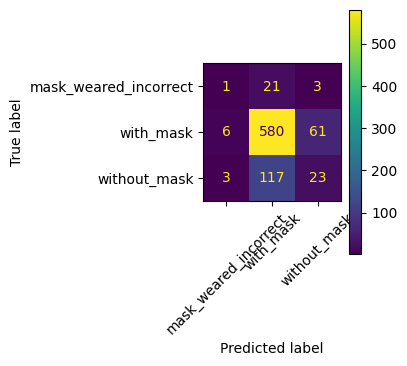

In [ ]:

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
(train_idx, test_idx), = sss.split(X, y_enc)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]

use_scaler = (FEAT_TYPE != "lbp") 
def make_pipeline_svm(kernel="linear"):
    steps = []
    if use_scaler:
        steps.append(("scaler", StandardScaler()))
    if kernel == "linear":
        steps.append(("clf", LinearSVC()))
        return Pipeline(steps), {"clf__C":[0.1,1,3,10]}
    else:
        steps.append(("clf", SVC()))
        return Pipeline(steps), {"clf__C":[0.5,1,3,10], "clf__gamma":["scale","auto"], "clf__kernel":["rbf"]}

def make_pipeline_knn():
    steps = []
    if use_scaler:
        steps.append(("scaler", StandardScaler()))
    steps.append(("clf", KNeighborsClassifier()))
    return Pipeline(steps), {"clf__n_neighbors":[3,5,7,9], "clf__weights":["uniform","distance"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = []
pipelines.append(("LinearSVM",)+make_pipeline_svm("linear"))
pipelines.append(("RBFSVM",)+make_pipeline_svm("rbf"))
pipelines.append(("KNN",)+make_pipeline_knn())

best_model = None
best_name = None
best_score = -1

for name, pipe, grid in pipelines:
    gs = GridSearchCV(pipe, grid, cv=cv, n_jobs=-1, scoring="f1_macro", verbose=0)
    gs.fit(X_train, y_train)
    score = gs.best_score_
    print(f"{name}: best CV f1_macro={score:.4f} | params={gs.best_params_}")
    if score > best_score:
        best_score = score
        best_model = gs.best_estimator_
        best_name = name

print("Escolhido:", best_name, "CV f1_macro:", best_score)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

dump(best_model, MODELS_DIR / f"best_{FEAT_TYPE}_{best_name}.pkl")
dump(le, MODELS_DIR / "label_encoder.pkl")
with open(MODELS_DIR / "config.json","w") as f:
    json.dump({"feat_type": FEAT_TYPE}, f, indent=2)



## 5) Detecção de faces (usando Haar) e pipeline fim‑a‑fim

,image,mask_weared_incorrect,with_mask,without_mask
0,maksssksksss0.png,0,4,0
1,maksssksksss1.png,0,2,0
2,maksssksksss10.png,0,1,0
3,maksssksksss100.png,0,1,0
4,maksssksksss101.png,0,0,0


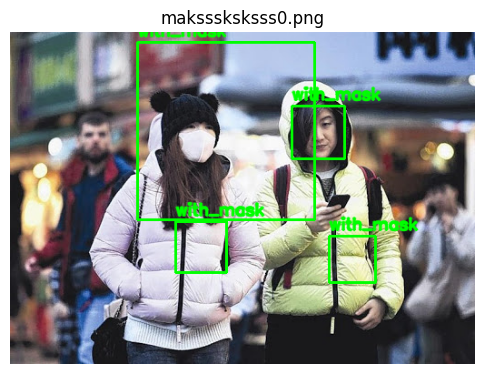

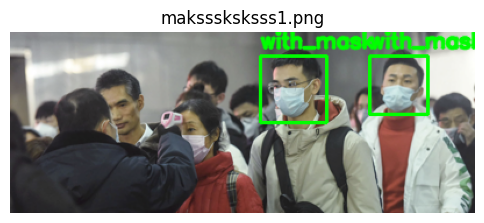

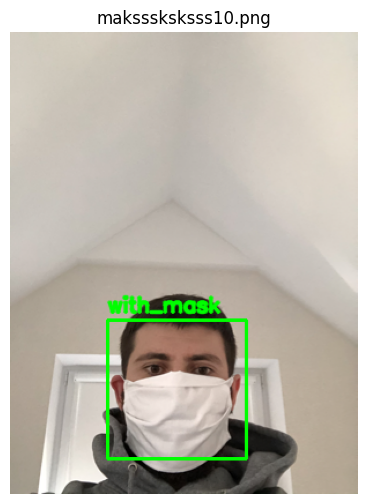

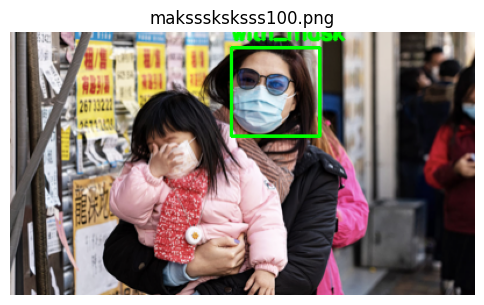

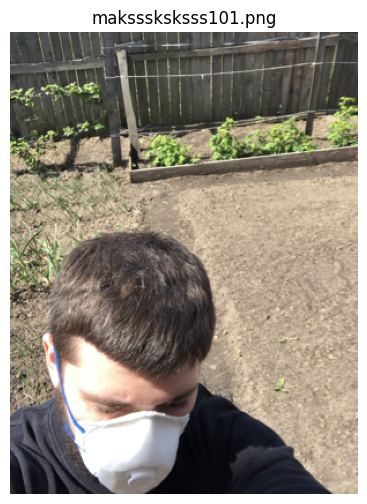

In [ ]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

FRONTAL = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
PROFILE = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_profileface.xml")

def detect_faces_haar(img, minSize=(30,30), scaleFactor=1.1, minNeighbors=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = []
    for det in [FRONTAL, PROFILE]:
        rects = det.detectMultiScale(gray, scaleFactor=scaleFactor, minNeighbors=minNeighbors, minSize=minSize)
        for (x, y, w, h) in rects:
            faces.append((x, y, x+w, y+h))
    keep = []
    for i, a in enumerate(faces):
        ax1, ay1, ax2, ay2 = a
        area_a = (ax2-ax1)*(ay2-ay1)
        ok = True
        for j, b in enumerate(faces):
            if i == j: 
                continue
            bx1, by1, bx2, by2 = b
            interx1, intery1 = max(ax1, bx1), max(ay1, by1)
            interx2, intery2 = min(ax2, bx2), min(ay2, by2)
            iw, ih = max(0, interx2-interx1), max(0, intery2-intery1)
            inter = iw*ih
            area_b = (bx2-bx1)*(by2-by1)
            iou = inter / max(area_a + area_b - inter, 1)
            if iou > 0.5 and area_b > area_a:
                ok = False; break
        if ok: keep.append(a)
    return keep

from joblib import load

model_candidates = sorted(MODELS_DIR.glob(f"best_{FEAT_TYPE}_*.pkl"))
if len(model_candidates) == 0:
    raise FileNotFoundError("Não encontrei o modelo salvo em 'models/'. Rode a célula de treino/validação antes.")
best_model = load(model_candidates[0])
le = load(MODELS_DIR / "label_encoder.pkl")

def preprocess_roi(gray, size=(128,128)):
    return cv2.resize(gray, size, interpolation=cv2.INTER_AREA)

def features_from_roi(gray):
    if FEAT_TYPE == "lbp":
        return feats_lbp(gray).reshape(1, -1)
    elif FEAT_TYPE == "hog":
        return feats_hog(gray).reshape(1, -1)
    elif FEAT_TYPE == "lbp+hog":
        return np.concatenate([feats_lbp(gray), feats_hog(gray)]).reshape(1, -1)
    else:
        raise ValueError("FEAT_TYPE inválido")

def infer_image(img_path, visualize=True, save_path=None):
    img_path = Path(img_path)
    img = cv2.imread(str(img_path))
    if img is None: 
        return None
    faces = detect_faces_haar(img, minSize=(40,40), scaleFactor=1.08, minNeighbors=5)
    counts = {c:0 for c in le.classes_}
    for (x1,y1,x2,y2) in faces:
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            continue
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = preprocess_roi(gray)
        f = features_from_roi(gray)
        pred = best_model.predict(f)[0]
        label = le.inverse_transform([pred])[0] if isinstance(pred, (int,np.integer)) else pred
        counts[label] += 1
        if visualize:
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(img, label, (x1, max(0,y1-7)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)
    if visualize:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,6))
        plt.imshow(rgb); plt.axis('off'); plt.title(img_path.name)
        if save_path:
            cv2.imwrite(str(save_path), img)
    return counts, faces

base_dir = IMG_DIR if Path(IMG_DIR).exists() else DATA_RAW
sample_imgs = sorted(Path(base_dir).rglob("*.png"))[:5]
if len(sample_imgs) == 0:
    sample_imgs = sorted(Path(base_dir).rglob("*.jpg"))[:5]
if len(sample_imgs) == 0:
    sample_imgs = sorted(Path(DATA_RAW).rglob("*.png"))[:5]
if len(sample_imgs) == 0:
    sample_imgs = sorted(Path(DATA_RAW).rglob("*.jpg"))[:5]

all_counts = []
for p in sample_imgs:
    outp = FIG_DIR / f"infer_{Path(p).stem}.png"
    res = infer_image(p, visualize=True, save_path=outp)
    if res is not None:
        counts, faces = res
        all_counts.append({"image": Path(p).name, **counts})

df_counts = pd.DataFrame(all_counts).fillna(0)
df_counts


## 6) Exportar contagens por imagem

In [9]:

import pandas as pd
csv_out = ROOT / "reports" / "pred_counts.csv"
df_counts.to_csv(csv_out, index=False)
print("CSV salvo em:", csv_out)


CSV salvo em: C:\Users\Fernanda\Desktop\projeto_mascara\reports\pred_counts.csv
